# High level sequencing summary statistics

In [4]:
library(tidyverse)
library(data.table)
library(RColorBrewer)

dir <- "/mnt/thechenlab/Dawn/splicing/library_sequencing_V2/RNA_V2_results_Mounica/"
bc_lib_table_dir <- "/mnt/thechenlab/Dawn/splicing/library_sequencing_V2/DNA_V2_V3_out/"
figure_outdir <- "/mnt/dawnccle2/melange/figures_outputs/figS01"
# Create the output directory if it doesn't exist.
if (!dir.exists(figure_outdir)) {
  dir.create(figure_outdir, recursive = TRUE)
}

cellline_metadata <- read_csv("/mnt/dawnccle2/melange/process_fastq_250221/02_merge_and_normalize_counts/cellline_sample_metadata_v4.csv")
cellline_metadata

Rows: 311 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): filename, basename, sample, condition, rep_old, rep_new, sample_new
dbl (13): total_reads, total_aligned_reads, total_umi_count, duplication_rat...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


filename,basename,sample,condition,rep_old,rep_new,sample_new,total_reads,total_aligned_reads,total_umi_count,duplication_rate,bc_not_found,perc_bc_not_found,skipped_reads,chimera_reads,perc_chimera_reads,unspliced_counter,minor_splice_counter,perfect_middle_exon,everything_passed_with_middle_exon
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
/mnt/dawnccle2/processed_data/reprocess_250221/K562//K562_K700E-H04_S262_umi_dedup_fine_grained_idx.csv,K562_K700E-H04_S262_umi_dedup_fine_grained_idx.csv,K562_K700E-H04_S262,K562K700E,rep1,rep1,K562K700E-rep1,41505772,38917674,6485351,0.16664282,1372050,0.03305685,8225067,4981475,0.1804379,980429,2104483,21672203,22626220
/mnt/dawnccle2/processed_data/reprocess_250221/K562//K562_K700E-H05_S263_umi_dedup_fine_grained_idx.csv,K562_K700E-H05_S263_umi_dedup_fine_grained_idx.csv,K562_K700E-H05_S263,K562K700E,rep2,rep2,K562K700E-rep2,42735524,40157575,6221726,0.15493281,1424120,0.03332403,8562758,5064171,0.1781566,1070625,2098807,22369654,23361214
/mnt/dawnccle2/processed_data/reprocess_250221/K562//K562_K700E-H06_S264_umi_dedup_fine_grained_idx.csv,K562_K700E-H06_S264_umi_dedup_fine_grained_idx.csv,K562_K700E-H06_S264,K562K700E,rep3,rep3,K562K700E-rep3,36274891,34036200,4406776,0.12947321,1205193,0.03322389,7064888,4282589,0.1750220,775212,1727235,19354731,20186276
/mnt/dawnccle2/processed_data/reprocess_250221/K562//K562_WT-H01_S259_umi_dedup_fine_grained_idx.csv,K562_WT-H01_S259_umi_dedup_fine_grained_idx.csv,K562_WT-H01_S259,K562WT,rep1,rep1,K562WT-rep1,73478733,69208355,4722380,0.06823425,2394265,0.03258446,11296555,9266588,0.1739006,927989,3697125,42404569,44020098
/mnt/dawnccle2/processed_data/reprocess_250221/K562//K562_WT-H02_S260_umi_dedup_fine_grained_idx.csv,K562_WT-H02_S260_umi_dedup_fine_grained_idx.csv,K562_WT-H02_S260,K562WT,rep2,rep2,K562WT-rep2,92707992,87249310,6624051,0.07592096,3114571,0.03359550,17474511,11029645,0.1711652,1185136,4151075,51390573,53408943
/mnt/dawnccle2/processed_data/reprocess_250221/K562//K562_WT-H03_S261_umi_dedup_fine_grained_idx.csv,K562_WT-H03_S261_umi_dedup_fine_grained_idx.csv,K562_WT-H03_S261,K562WT,rep3,rep3,K562WT-rep3,53634921,50352253,4243504,0.08427635,1792567,0.03342164,9787663,6441872,0.1711796,616641,2315697,30029113,31190380
/mnt/dawnccle2/processed_data/reprocess_250221/nova230516//769P-rep1_umi_dedup_fine_grained_idx.csv,769P-rep1_umi_dedup_fine_grained_idx.csv,769P-rep1,769P,rep1,rep1,769P-rep1,43846612,41249326,2431151,0.05893796,1448518,0.03303603,9770035,5517950,0.1931217,1033852,1873043,22008462,23054446
/mnt/dawnccle2/processed_data/reprocess_250221/nova230516//769P-rep2_umi_dedup_fine_grained_idx.csv,769P-rep2_umi_dedup_fine_grained_idx.csv,769P-rep2,769P,rep2,rep2,769P-rep2,49465181,46383549,2888290,0.06226971,1631880,0.03299048,11211870,6419912,0.2009727,1137722,2089750,24364161,25524295
/mnt/dawnccle2/processed_data/reprocess_250221/nova230516//769P-rep3_umi_dedup_fine_grained_idx.csv,769P-rep3_umi_dedup_fine_grained_idx.csv,769P-rep3,769P,rep3,rep3,769P-rep3,45547717,42858467,2612690,0.06096088,1524717,0.03347516,10193087,5899798,0.1993908,1082177,1994087,22613880,23689318


`summarise()` has grouped output by 'sample_new', 'condition'. You can override
using the `.groups` argument.


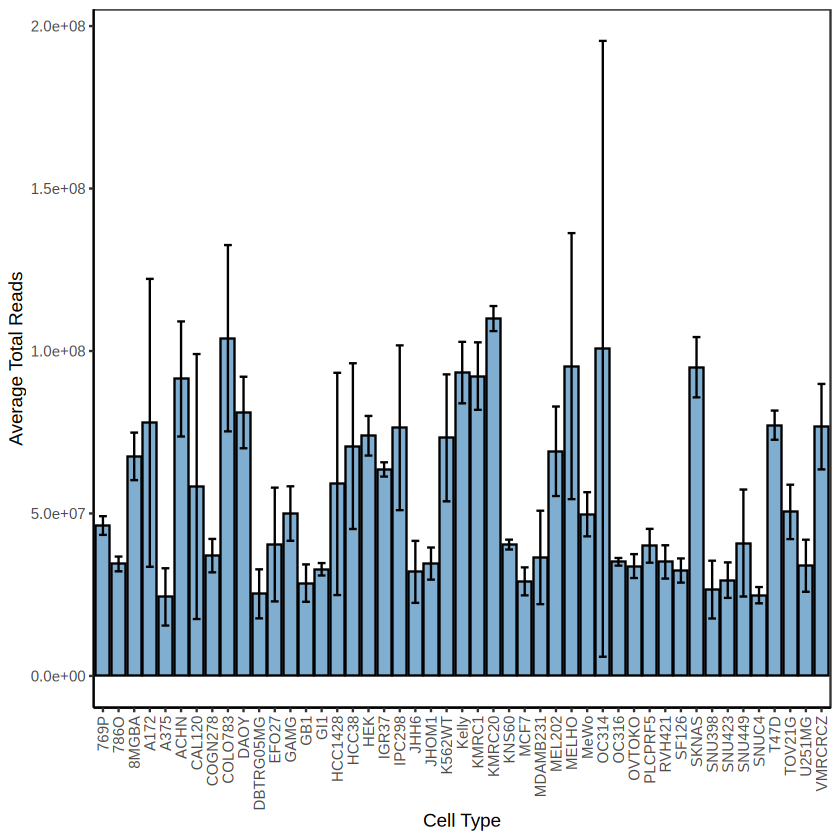

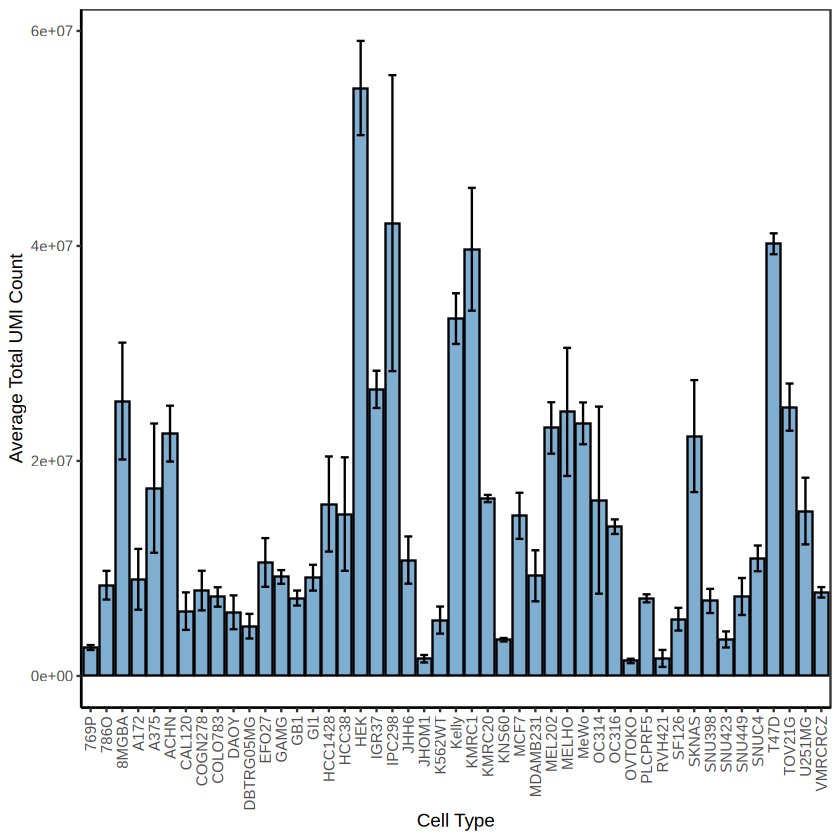

In [5]:
cellline_metadata_aggregated <- cellline_metadata %>%
  filter(!str_detect(sample_new, "MUT|splicelib|CH3|FUBP1|RBM|ZRSR|K562K700E")) %>%
  # There's another K562WT in the data. 
  filter(condition != "K562") %>%
  group_by(sample_new, condition, rep_new) %>%
  summarise(total_reads = sum(total_reads),
            total_umi_count = sum(total_umi_count))

# print(head(cellline_metadata_aggregated))
#   sample_new condition rep_new total_reads total_umi_count
#   <chr>      <chr>     <chr>         <dbl>           <dbl>
# 1 769P-rep1  769P      rep1       43846612         2431151
# 2 769P-rep2  769P      rep2       49465181         2888290
# 3 769P-rep3  769P      rep3       45547717         2612690
# 4 786O-rep1  786O      rep1       31847145         9882928
# 5 786O-rep2  786O      rep2       35909859         8191264
# 6 786O-rep3  786O      rep3       35647124         7246684

# Calculate average total reads and total UMI count per condition, with error bars.
cellline_metadata_aggregated_summary <- cellline_metadata_aggregated %>%
  group_by(condition) %>%
  summarise(mean_total_reads = mean(total_reads),
            mean_total_umi_count = mean(total_umi_count),
            sd_total_reads = sd(total_reads),
            sd_total_umi_count = sd(total_umi_count))

# Plot the average total reads and total UMI count per condition, with error bars.
# Total reads plot
ggplot(cellline_metadata_aggregated_summary, aes(x = condition, y = mean_total_reads)) +
  geom_bar(stat = "identity", fill = "#80AED1", color = "black") +
  geom_errorbar(aes(ymin = mean_total_reads - sd_total_reads, ymax = mean_total_reads + sd_total_reads), width = 0.5) +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12),
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)) +
  xlab("Cell Type") +
  ylab("Average Total Reads")
ggsave(file.path(figure_outdir, "figS01_total_reads_by_condition.pdf"), width = 1200, height = 500, units = "px", dpi = 150)

# Total UMI count plot
ggplot(cellline_metadata_aggregated_summary, aes(x = condition, y = mean_total_umi_count)) +
  geom_bar(stat = "identity", fill = "#80AED1", color = "black") +
  geom_errorbar(aes(ymin = mean_total_umi_count - sd_total_umi_count, ymax = mean_total_umi_count + sd_total_umi_count), width = 0.5) +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12),
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)) +
  xlab("Cell Type") +
  ylab("Average Total UMI Count")
ggsave(file.path(figure_outdir, "figS01_total_umi_by_condition.pdf"), width = 1200, height = 500, units = "px", dpi = 150)


In [19]:
# Mean total reads and standard deviation
cat("Mean total reads:", format(round(mean(cellline_metadata_aggregated$total_reads), 1), big.mark=","), "\n")
cat("SD total reads:", format(round(sd(cellline_metadata_aggregated$total_reads), 1), big.mark=","), "\n\n")

# Mean total UMI count and standard deviation  
cat("Mean total UMI count:", format(round(mean(cellline_metadata_aggregated$total_umi_count), 1), big.mark=","), "\n")
cat("SD total UMI count:", format(round(sd(cellline_metadata_aggregated$total_umi_count), 1), big.mark=","), "\n\n")

# Get how many umi per barcodes.46,372 barcodes. 
cat("UMI per barcode:", format(round(mean(cellline_metadata_aggregated$total_umi_count) / 46372, 1), big.mark=","), "\n")

Mean total reads: 55,982,309 
SD total reads: 30,705,250 

Mean total UMI count: 14,872,879 
SD total UMI count: 12,284,491 

UMI per barcode: 320.7 


# Plot cross sample replicate correlation

In [6]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)

# Now I kinda want to plot the heatmap. 
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(condition %in% c("K562WT", "K562K700E"))) %>% 
  filter(!(condition %in% c("JHOM1", "RVH421", "KNS60", "OVTOKO"))) %>% 
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 30) %>%
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":") %>% 
  mutate(upstream_offset = as.integer(upstream_offset)) %>% 
  mutate(downstream_offset = as.integer(downstream_offset)) %>%
  mutate(const_offset = as.integer(const_offset)) %>% 
  filter(abs(upstream_offset) != 1 & abs(downstream_offset)!= 1) %>% 
  dplyr::select(-upstream_offset, -downstream_offset, -const_offset) %>% 
  dplyr::select(-index, -mode) %>%
  mutate(PSI = included_count/(included_count + skipped_count))
# Filter out the sequences that are in the blacklist.
blacklist_sequences <- read.csv("/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_samples_blacklist_sequences.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(index_offset %in% blacklist_sequences$index_offset))

dt <- as.data.table(final_psi_table_filtered)

# Compute PSI by condition efficiently
psi_by_condition <- dt[, .(PSI = mean(PSI, na.rm = TRUE), num_rep = .N), by = .(condition, index_offset)][
  num_rep >= 2, .(condition, index_offset, PSI)]  # Filter out groups with <2 replicates

psi_table_pivot <- psi_by_condition %>%
  select(condition, index_offset, PSI) %>%
  pivot_wider(names_from = c(condition), values_from = PSI)

psi_table_pivot_sample <- final_psi_table_filtered %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = c(sample), values_from = PSI) 

# Convert to matrix.
psi_table_mat <- as.matrix(psi_table_pivot_sample %>% select(-index_offset))
rownames(psi_table_mat) <- psi_table_pivot_sample$index_offset


# psi_table_pivot_by_condition_mat <- as.matrix(psi_table_pivot %>% select(-index_offset))
# rownames(psi_table_pivot_by_condition_mat) <- psi_table_pivot$index_offset
# # Filter out rows with >10% NAs.
# psi_table_pivot_by_condition_mat <- psi_table_pivot_by_condition_mat[rowMeans(is.na(psi_table_pivot_by_condition_mat)) < 0.1, ]

# # color_palette2 <- c("#4575B4", "#80AED1", "#DFF2F6", "#FFE7B8", "#F08944", "#D83629")
# color_palette2 <- c(
#   "#4575B4",  # deep blue
#   "#85B6D6",  # slightly lighter/more even blue
#   "#E2EFF2",  # less stark pastel blue
#   "#FFE3B0",  # warmer, slightly less saturated yellow
#   "#EF9651",  # softer orange
#   "#D83629"   # red
# )
# color_palette2_custom <- colorRampPalette(color_palette2)(100)
# color_palette2_custom_rev <- colorRampPalette(rev(color_palette2))(100)


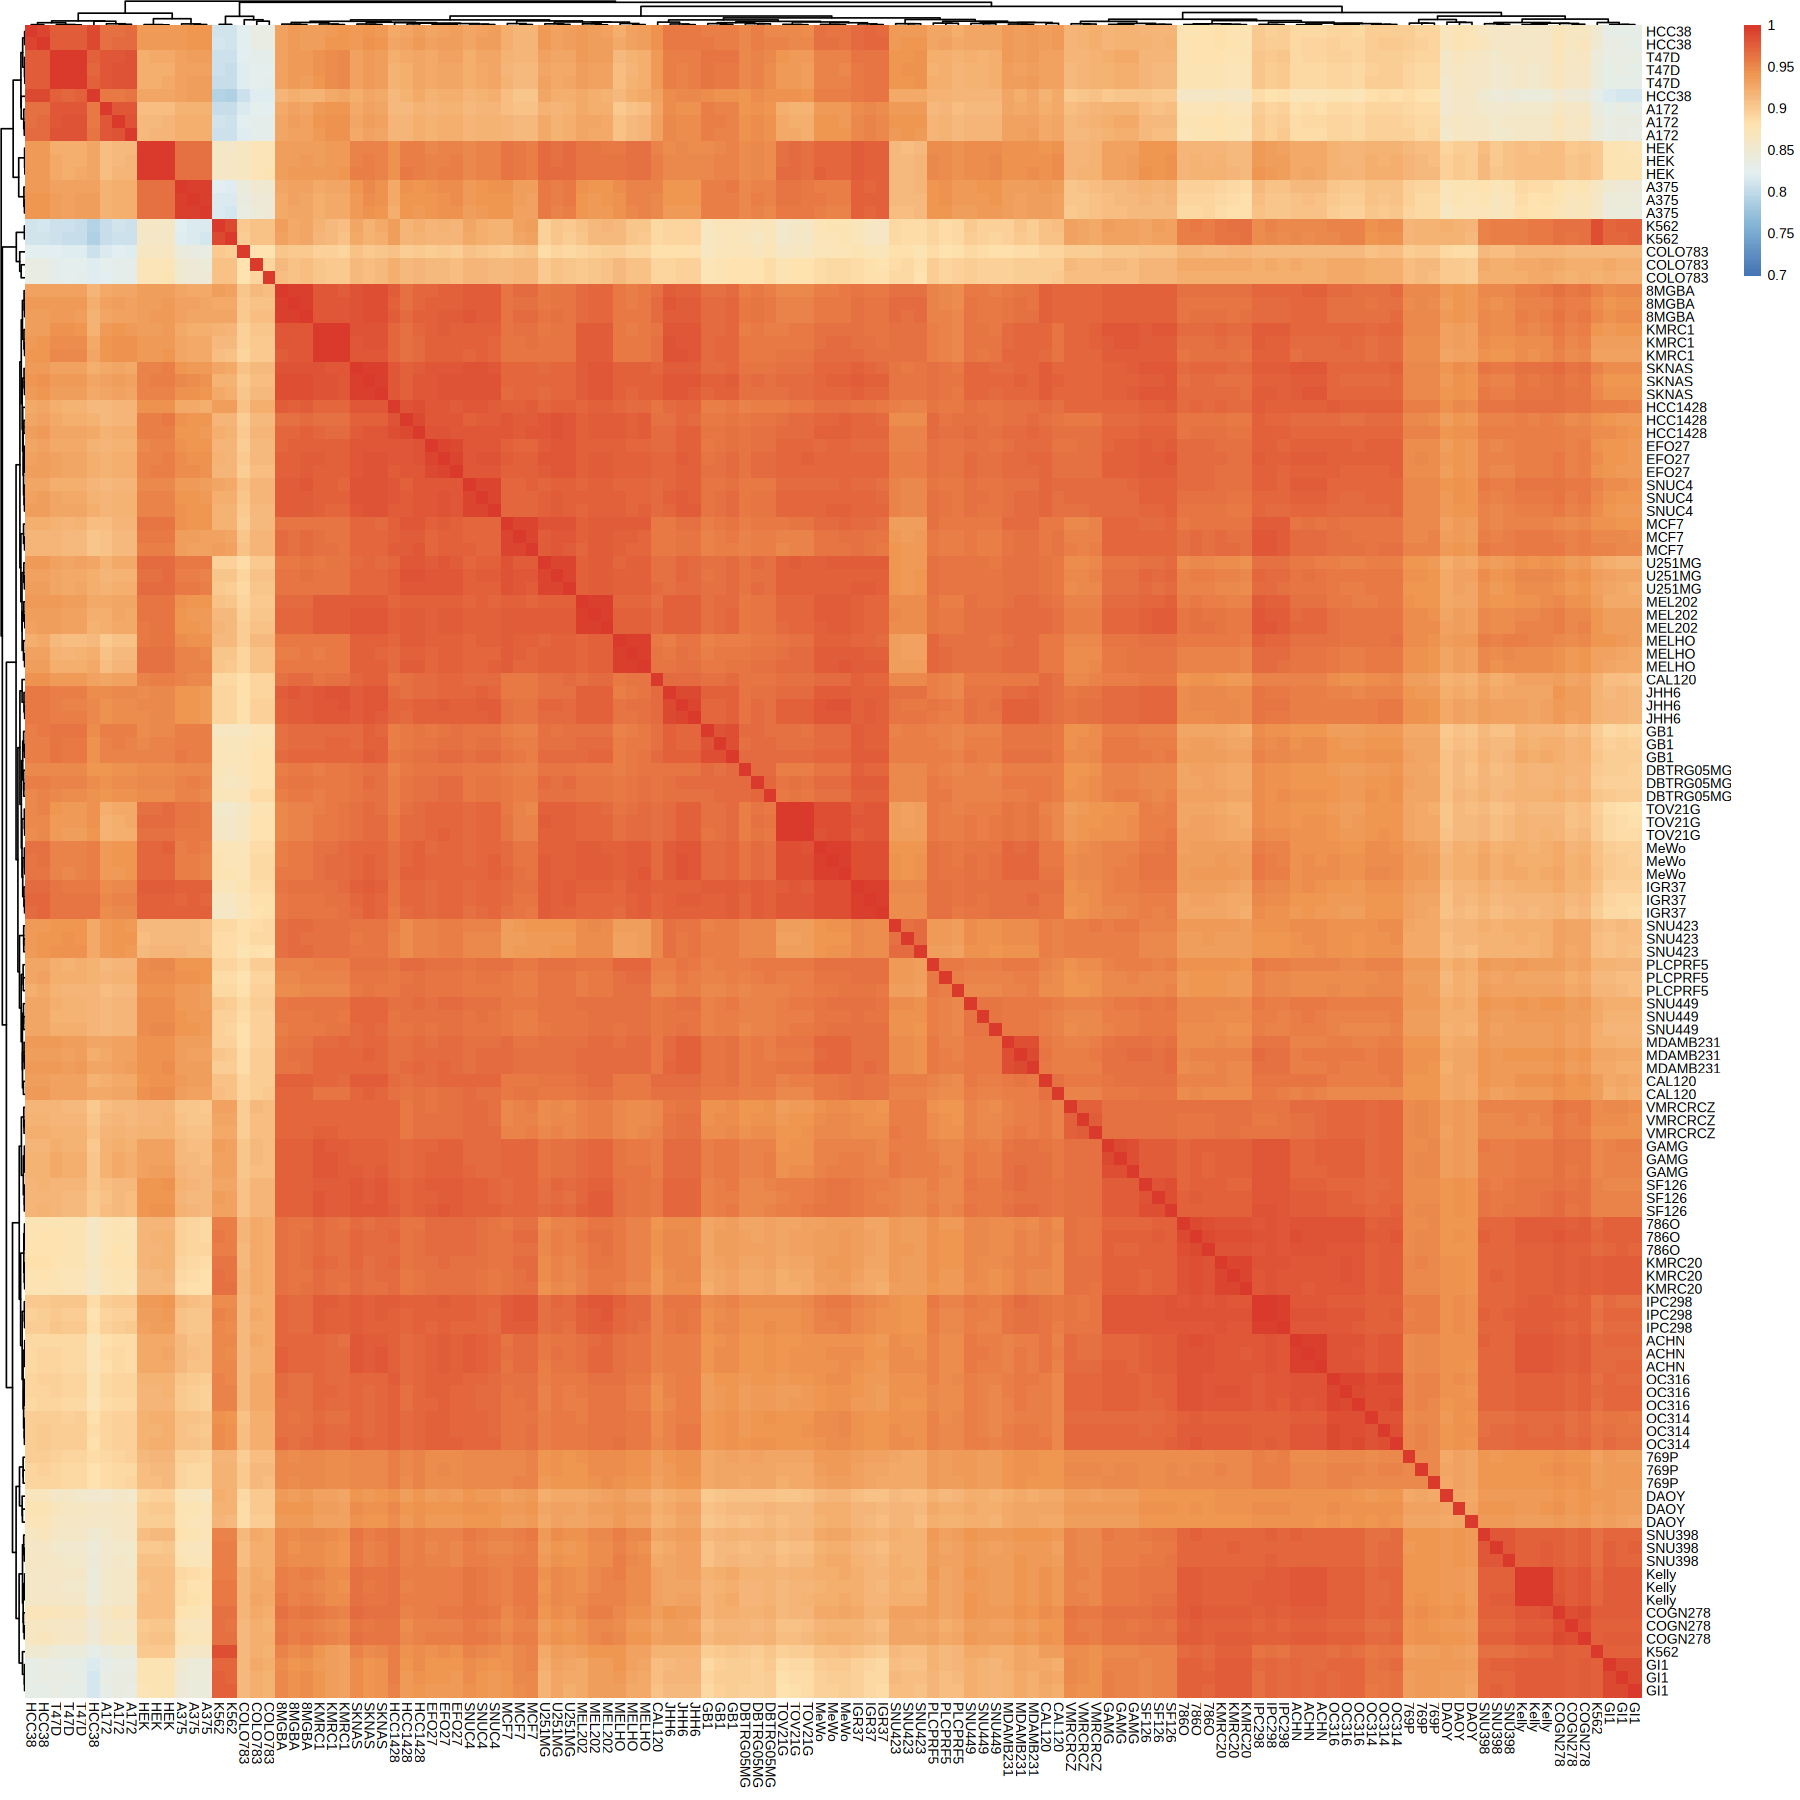

In [7]:
options(repr.plot.width=15, repr.plot.height=15)  # Set larger plot size for notebook display

# Filter to rows with < 10% NAs.
psi_table_mat <- psi_table_mat[rowMeans(is.na(psi_table_mat)) < 0.1, ]
# Calculate cross replicate correlation.
cor_matrix <- cor(psi_table_mat, method = "pearson", use = "pairwise.complete.obs")

# Modify row and column names to remove -repX
rownames(cor_matrix) <- gsub("-rep[0-9]", "", rownames(cor_matrix))
colnames(cor_matrix) <- gsub("-rep[0-9]", "", colnames(cor_matrix))

# color_palette2 <- c("#4575B4", "#80AED1", "#DFF2F6", "#FFE7B8", "#F08944", "#D83629")
color_palette2 <- c(
  "#4575B4",  # deep blue
  "#85B6D6",  # slightly lighter/more even blue
  "#E2EFF2",  # less stark pastel blue
  "#FFE3B0",  # warmer, slightly less saturated yellow
  "#EF9651",  # softer orange
  "#D83629"   # red
)
color_palette2_custom <- colorRampPalette(color_palette2)(100)
color_palette2_custom_rev <- colorRampPalette(rev(color_palette2))(100)
# Plot with pheatmap.
p1 <- pheatmap(cor_matrix,
         color = color_palette2_custom,
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         fontsize = 8,
         border_color = NA,
         treeheight_row = 10,
         treeheight_col = 10,
         show_rownames = TRUE,
         show_colnames = TRUE,
         breaks = seq(0.7, 1, length.out = 100))
ggsave(file.path(figure_outdir, "figS01_correlation_heatmap.pdf"),  plot = p1, width = 24, height = 24, dpi = 300)

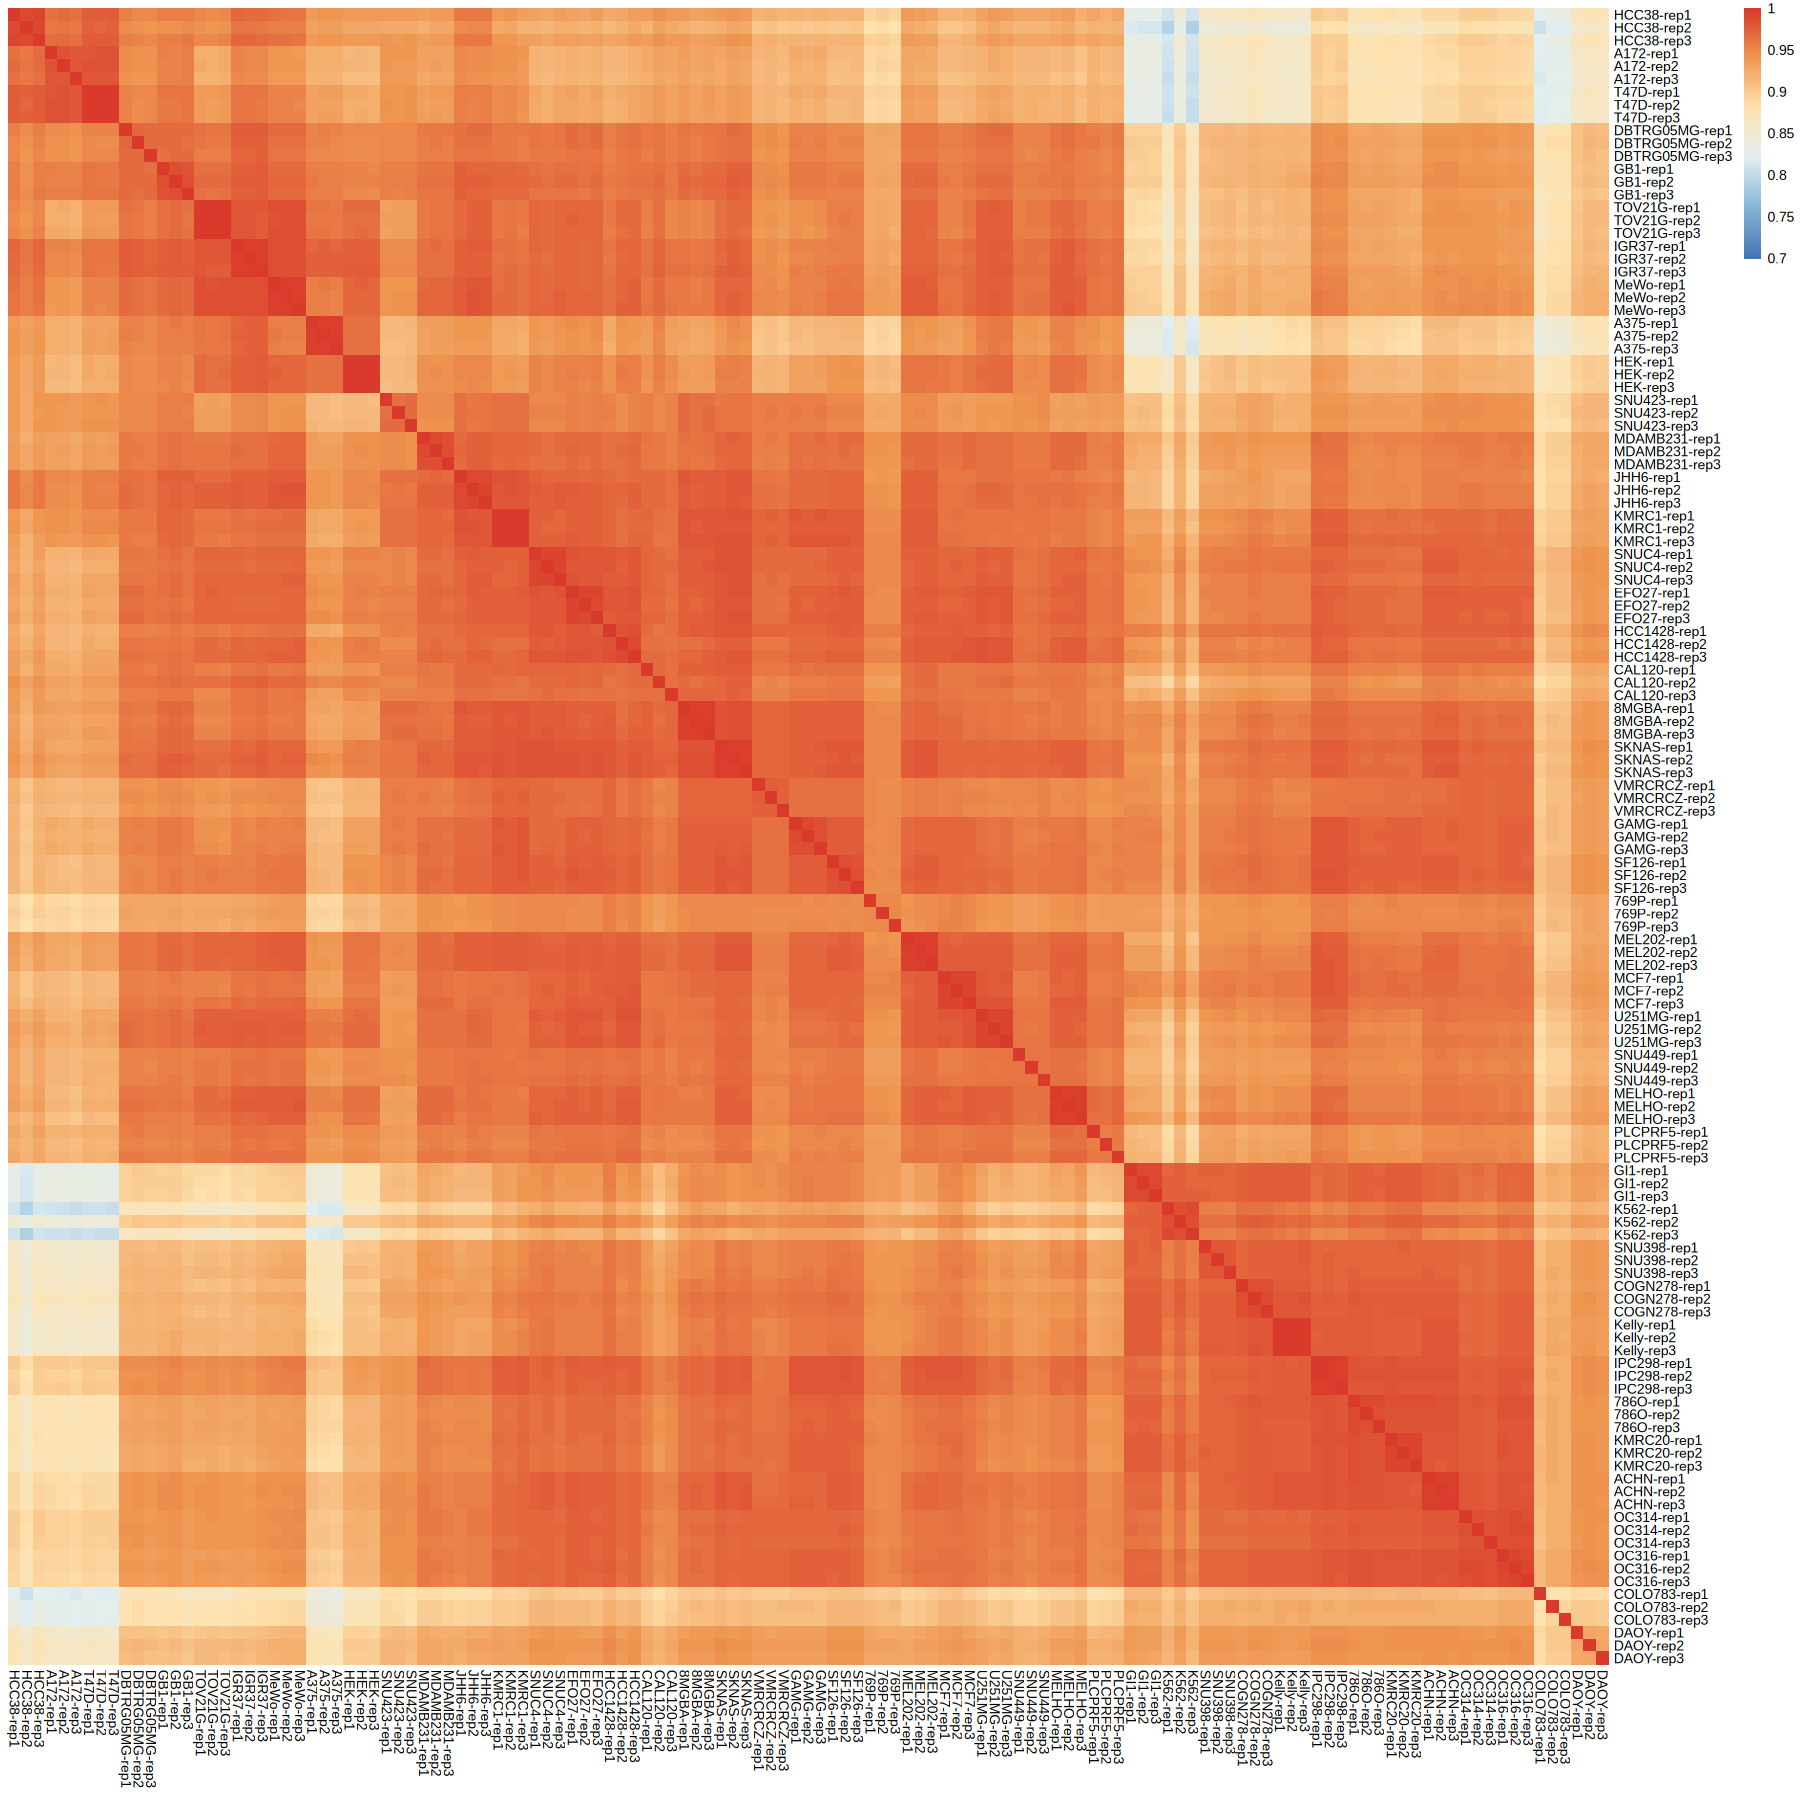

In [49]:
options(repr.plot.width=15, repr.plot.height=15)

# Filter to rows with < 10% NAs.
psi_table_mat <- psi_table_mat[rowMeans(is.na(psi_table_mat)) < 0.1, ]

# Check if psi_table_mat is empty after filtering
if (nrow(psi_table_mat) == 0 || ncol(psi_table_mat) == 0) {
  stop("No data remains after filtering - check psi_table_mat dimensions")
}

# Extract cell type (remove -repX suffix) 
cell_types <- gsub("-rep[0-9]+", "", colnames(psi_table_mat))
names(cell_types) <- colnames(psi_table_mat)

# Compute average PSI per cell type (across replicates)
psi_avg_by_celltype <- t(sapply(unique(cell_types), function(ct) {
  rowMeans(psi_table_mat[, cell_types == ct, drop = FALSE], na.rm = TRUE)
}))

# Cluster cell types
celltype_dist <- dist(psi_avg_by_celltype)
celltype_hclust <- hclust(celltype_dist)
celltype_order <- celltype_hclust$labels[celltype_hclust$order]

# Order samples: clustered cell types, replicates preserved within
ordered_samples <- unlist(sapply(celltype_order, function(ct) {
  sort(grep(paste0("^", ct, "-rep[0-9]+$"), colnames(psi_table_mat), value = TRUE))
}))

# Compute correlation matrix using the new sample order
cor_matrix <- cor(psi_table_mat[, ordered_samples], method = "pearson", use = "pairwise.complete.obs")

# Optional: prepare color palette
color_palette2 <- c(
  "#4575B4", "#85B6D6", "#E2EFF2", "#FFE3B0", "#EF9651", "#D83629"
)
color_palette2_custom <- colorRampPalette(color_palette2)(100)

# Plot
p2 <- pheatmap(cor_matrix,
         color = color_palette2_custom,
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         fontsize = 8,
         border_color = NA,
         treeheight_row = 10,
         treeheight_col = 10,
         show_rownames = TRUE,
         show_colnames = TRUE,
         breaks = seq(0.7, 1, length.out = 100))

ggsave(file.path(figure_outdir, "figS01_correlation_heatmap_clustered.pdf"),  plot = p2, width = 24, height = 24, dpi = 300)

# Clustering by tissue type

In [48]:
##############################################################
##### Plot Clustering by tissue type #########################
##############################################################
library(ggplot2)
library(ggrepel)
library(viridis)
library(umap)
library(dplyr)
library(readr)
library(tidyr)
library(FactoMineR)

figure_outdir <- "/mnt/dawnccle2/melange/figures_outputs/figS01"

# Load metadata
cellline_metadata <- read_csv("/mnt/dawnccle2/melange/data/FINAL_SET_cellline_metadata_v1.csv") %>% 
  select(StrippedName, `Disease Subtype`, lineage)

# Preprocess PSI matrix
psi_table_mat_clean <- psi_table_pivot %>%
  select(-index_offset) %>%
  mutate(across(everything(), as.numeric)) %>%  # Convert to numeric
  select(-HEK, -`769P`)

# Change the Kelly column to KELLY
colnames(psi_table_mat_clean) <- gsub("Kelly", "KELLY", colnames(psi_table_mat_clean))

# Remove rows that have > 10% NA
psi_table_mat_clean <- psi_table_mat_clean[rowMeans(is.na(psi_table_mat_clean)) <= 0.01, ]

# Replace NA values with row medians
psi_table_mat_clean <- psi_table_mat_clean %>%
  mutate(across(everything(), ~ replace_na(., median(., na.rm = TRUE))))

# Convert to matrix
psi_matrix <- as.matrix(psi_table_mat_clean)

# Ensure row names are properly assigned
rownames(psi_matrix) <- psi_table_pivot$index_offset[1:nrow(psi_matrix)]

# Remove rows with zero variance (needed for PCA & UMAP)
psi_matrix <- psi_matrix[apply(psi_matrix, 1, var, na.rm = TRUE) > 0, ]

# **Transpose the matrix** (samples = rows, features = columns)
psi_matrix_t <- t(psi_matrix)

### --- PCA ANALYSIS --- ###

# Perform PCA
pca_result <- prcomp(psi_matrix_t, center = TRUE, scale. = TRUE)

# Extract PCA scores
pca_scores <- as.data.frame(pca_result$x) %>%
  rownames_to_column(var = "StrippedName") %>%
  left_join(cellline_metadata, by = "StrippedName") %>% 
  distinct()

# Extract variance explained for axis labels
pca_var_explained <- summary(pca_result)$importance[2, ] * 100  # Percentage variance explained

# Plot PCA
pca_plot <- ggplot(pca_scores, aes(x = PC1, y = PC2, color = lineage, label = StrippedName)) +
  geom_point(alpha = 1, size = 3) +  # Solid dots with full opacity
  scale_color_manual(values = c("#1f77b4", "#2ca02c", "#9467bd", "#d62728",
                               "#ff7f0e", "#8c564b", "#e377c2", "#7f7f7f", 
                               "#17becf", "#bcbd22")) +  # Darker, more distinct colors
  # geom_text_repel(aes(label = StrippedName), size = 3, box.padding = 0.5) +  # Add sample labels
  labs(
    title = "PCA of PSI Values", 
    x = paste0("PC1 (", round(pca_var_explained[1], 1), "% Variance)"),
    y = paste0("PC2 (", round(pca_var_explained[2], 1), "% Variance)"),
    color = "Disease Type"
  ) +
  theme_classic(base_size = 16) +  # Classic theme without grid lines
  theme(
    panel.grid = element_blank(),  # Remove grid lines
    axis.line = element_line(size = 1),  # Keep x/y axis lines
    legend.position = "right", 
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 16),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(size = 14),
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

ggsave(file.path(figure_outdir, "figS01_pca_plot.pdf"),
       plot = pca_plot,
       width = 8, height = 5, dpi = 300)  # High DPI for publication quality


Rows: 47 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): StrippedName, DepMap_ID, CCLE_Name, primary_disease, Subtype, Dise...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:

#  ### --- UMAP ANALYSIS --- ###

# # Perform UMAP
# umap_result <- umap(psi_matrix_t)

# # Extract UMAP scores
# umap_scores <- as.data.frame(umap_result$layout) %>%
#   rownames_to_column(var = "StrippedName") %>%
#   rename(UMAP1 = V1, UMAP2 = V2) %>%
#   left_join(cellline_metadata, by = "StrippedName") %>% 
#   distinct()

# # Plot UMAP
# umap_plot <- ggplot(umap_scores, aes(x = UMAP1, y = UMAP2, color = Disease, label = StrippedName)) +
#   geom_point(alpha = 0.8, size = 3) +  # Solid dots
#   scale_color_brewer(palette = "Set1") +  
#   geom_text_repel(aes(label = StrippedName), size = 3, box.padding = 0.5) +  # Add sample labels
#   labs(
#     title = "UMAP of PSI Values",
#     x = "UMAP1",
#     y = "UMAP2",
#     color = "Disease Type"
#   ) +
#   theme_classic(base_size = 16) +  # Classic theme without grid lines
#   theme(
#     panel.grid = element_blank(),  # Remove grid lines
#     axis.line = element_line(size = 1),  # Keep x/y axis lines
#     legend.position = "right",
#     legend.text = element_text(size = 14),
#     legend.title = element_text(size = 16),
#     axis.title = element_text(face = "bold"),
#     axis.text = element_text(size = 14),
#     plot.title = element_text(hjust = 0.5, face = "bold")
#   )

# ggsave(filename = paste0(output_filepath, "/umap_plot.pdf"), 
#        plot = umap_plot, 
#        width = 8, height = 6, dpi = 600)  # High DPI for publication quality

# # Plot UMAP
# umap_plot <- ggplot(umap_scores, aes(x = UMAP1, y = UMAP2, color = `Disease Subtype`, label = StrippedName)) +
#   geom_point(alpha = 0.8, size = 3) +  # Solid dots
#   scale_color_brewer(palette = "Set1") +  
#   geom_text_repel(aes(label = StrippedName), size = 3, box.padding = 0.5) +  # Add sample labels
#   labs(
#     title = "UMAP of PSI Values",
#     x = "UMAP1",
#     y = "UMAP2",
#     color = "Disease Type"
#   ) +
#   theme_classic(base_size = 16) +  # Classic theme without grid lines
#   theme(
#     panel.grid = element_blank(),  # Remove grid lines
#     axis.line = element_line(size = 1),  # Keep x/y axis lines
#     legend.position = "right",
#     legend.text = element_text(size = 14),
#     legend.title = element_text(size = 16),
#     axis.title = element_text(face = "bold"),
#     axis.text = element_text(size = 14),
#     plot.title = element_text(hjust = 0.5, face = "bold")
#   )

# ggsave(filename = paste0(output_filepath, "/umap_plot_subtype.pdf"), 
#        plot = umap_plot, 
#        width = 8, height = 6, dpi = 600)  # High DPI for publication quality
 
# # What are the sequences that contribute most to PC2? 
# # Get the loadings for PC2
# pca_loadings <- as.data.frame(pca_result$rotation) %>%
#   rownames_to_column(var = "index_offset") %>%
#   select(index_offset, PC2) %>%
#   arrange(desc(abs(PC2))) %>% 
#   head(20)
# # Plot PC2 loadings
# pca_loadings_plot <- ggplot(pca_loadings, aes(x = reorder(index_offset, PC2), y = PC2)) +
#   geom_bar(stat = "identity", fill = "#1f78b4", color = "black") +  # High contrast colors
#   coord_flip() +  # Horizontal bars
#   labs(
#     title = "Top Loadings for PC2",
#     x = "Index Offset",
#     y = "PC2 Loading"
#   ) +
#   theme_classic(base_size = 16) +  # Classic theme without grid lines
#   theme(
#     panel.grid = element_blank(),  # Remove grid lines
#     axis.line = element_line(size = 1),  # Keep x/y axis lines
#     axis.title = element_text(face = "bold"),
#     axis.text = element_text(size = 14),
#     plot.title = element_text(hjust = 0.5, face = "bold")
#   )
# # pheatmap of these top loadings
# top_loadings_mat <- as.matrix(psi_table_pivot_sample %>% 
#                                filter(index_offset %in% pca_loadings$index_offset) %>% 
#                                select(-index_offset))

# # Plot pheatmap
# pheatmap(
#   top_loadings_mat, 
#   cluster_rows = T, 
#   cluster_cols = F, 
#   color = viridis(100), 
#   breaks = seq(0, 1, length.out = 100), 
#   main = "Top Loadings for PC2",
#   show_rownames = T,
#   show_colnames = T 
# )

# Look at the CCLE RNAseq

In [1]:
library(data.table)
library(tidyverse)

# Read in the data.
SE_matrix <- fread("/mnt/dawnccle2/data/processed_rmats_output/SE_JC_matrix.txt")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks data.table::transpose()
✖ lubridate::wday() 

In [3]:
num_NA_per_row <- SE_matrix %>%
  rowwise() %>%
  mutate(fraction_data = 1 - sum(is.na(c_across(-ID))) / (ncol(SE_matrix) - 1)) %>%
  select(ID, fraction_data)

# Get the number of rows with fraction_data < 0.25.
num_rows_with_fraction_data_less_than_0.25 <- num_NA_per_row %>%
  filter(fraction_data < 0.25) %>%
  nrow()

# Get the number of rows with fraction_data < 0.5.
num_rows_with_fraction_data_less_than_0.5 <- num_NA_per_row %>%
  filter(fraction_data < 0.5) %>%
  nrow()

# Get the number of rows with fraction_data < 0.75. 
num_rows_with_fraction_data_less_than_0.75 <- num_NA_per_row %>%
  filter(fraction_data < 0.75) %>%
  nrow()

# Proportion of rows with fraction_data < 0.25.
prop_rows_with_fraction_data_less_than_0.25 <- num_rows_with_fraction_data_less_than_0.25 / nrow(SE_matrix)

# Proportion of rows with fraction_data < 0.5.
prop_rows_with_fraction_data_less_than_0.5 <- num_rows_with_fraction_data_less_than_0.5 / nrow(SE_matrix)

# Proportion of rows with fraction_data < 0.75.
prop_rows_with_fraction_data_less_than_0.75 <- num_rows_with_fraction_data_less_than_0.75 / nrow(SE_matrix)

# Print the results.
print(paste0("Proportion of rows with fraction_data < 0.25: ", prop_rows_with_fraction_data_less_than_0.25))
print(paste0("Proportion of rows with fraction_data < 0.5: ", prop_rows_with_fraction_data_less_than_0.5))
print(paste0("Proportion of rows with fraction_data < 0.75: ", prop_rows_with_fraction_data_less_than_0.75))  

[1] "Proportion of rows with fraction_data < 0.25: 0.867859522728809"
[1] "Proportion of rows with fraction_data < 0.5: 0.912771495069872"
[1] "Proportion of rows with fraction_data < 0.75: 0.938226119539919"
